# Model File

Models included:

- Logistic Regression
- Decision Tree
- K-Nearest Neighbors
- Random Forest
- Linear Regression
- Neural Network


## Libraries used



In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
    silhouette_score,
    roc_curve
)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
sns.set(style='whitegrid')


## Load Dataset




In [2]:

data = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Dataset shape:', data.shape)
display(data.head())


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic Data Check


In [3]:

print(data.info())
print()
print('Missing values:')
print(data.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Clean Data

This code cleans TotalCharges, converts Churn into numbers, and removes customerID because it is only an identifier.


In [4]:

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})


data = data.drop(columns=['customerID'])

print('Missing values after cleaning:')
print(data.isnull().sum())


Missing values after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Encode Categorical Columns



In [5]:

binary_map = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0,
    'Male': 1,
    'Female': 0,
}

binary_columns = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]

for col in binary_columns:
    data[col] = data[col].map(binary_map)

data = pd.get_dummies(
    data,
    columns=['InternetService', 'Contract', 'PaymentMethod'],
    dtype=int
)

display(data.head())


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


## Split And Scale Data


In [6]:

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scale_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test[scale_columns] = scaler.transform(X_test[scale_columns])



## Create Evaluation Function



In [7]:

def show_results(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(model_name, 'Results')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred))
    print('Recall:', recall_score(y_test, y_pred))
    print('F1-score:', f1_score(y_test, y_pred))
    print('ROC-AUC:', roc_auc_score(y_test, y_prob))
    print()
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print()
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

    return y_pred, y_prob


## Logistic Regression Hyperparameter Tuning


In [8]:
logistic_params = {
    'C': [0.01, 0.1, 1, 10, 100]
}

lr = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    logistic_params,
    n_iter=5,
    scoring='roc_auc',
    cv=5,
    random_state=42
)

lr.fit(X_train, y_train)
best_lr = lr.best_estimator_

print('Logistic Regression parameter values tested:', logistic_params)
print('Best Logistic Regression params:', lr.best_params_)
y_pred_lr, y_prob_lr = show_results(best_lr, X_test, y_test, 'Logistic Regression')


Logistic Regression parameter values tested: {'C': [0.01, 0.1, 1, 10, 100]}
Best Logistic Regression params: {'C': 100}
Logistic Regression Results
Accuracy: 0.7381121362668559
Precision: 0.5043177892918825
Recall: 0.7807486631016043
F1-score: 0.6128016789087093
ROC-AUC: 0.8402748714769175

Confusion Matrix:
[[748 287]
 [ 82 292]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Logistic Regression Hyperparameter Graph


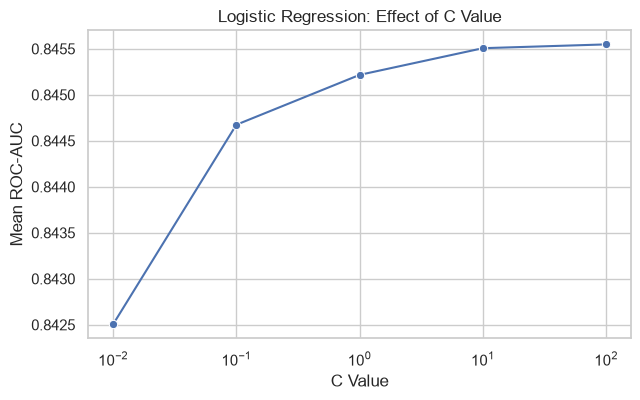

Best C value: 100


In [9]:
lr_results = pd.DataFrame(lr.cv_results_)
lr_results['C Value'] = lr_results['param_C'].astype(float)

plt.figure(figsize=(7, 4))
sns.lineplot(data=lr_results, x='C Value', y='mean_test_score', marker='o')
plt.xscale('log')
plt.title('Logistic Regression: Effect of C Value')
plt.xlabel('C Value')
plt.ylabel('Mean ROC-AUC')
plt.show()

print('Best C value:', lr.best_params_['C'])


## Logistic Regression Decision Threshold Tuning


,Threshold,Accuracy,Precision,Recall,F1-score
0,0.3,0.651526,0.427689,0.925134,0.584954
1,0.4,0.697658,0.462751,0.863636,0.602612
2,0.5,0.738112,0.504318,0.780749,0.612802
3,0.6,0.765791,0.545267,0.708556,0.616279
4,0.7,0.789922,0.604278,0.604278,0.604278


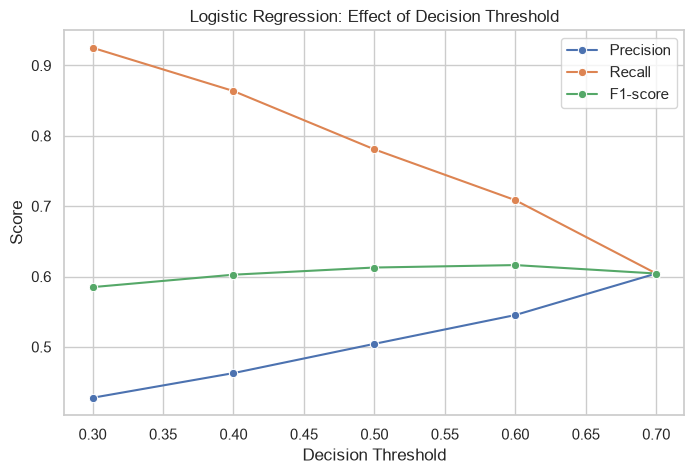

Best threshold by F1-score: 0.6


In [ ]:
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_threshold = (y_prob_lr >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred_threshold),
        'Precision': precision_score(y_test, y_pred_threshold, zero_division=0),
        'Recall': recall_score(y_test, y_pred_threshold, zero_division=0),
        'F1-score': f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)
display(threshold_results)

plt.figure(figsize=(8, 5))
sns.lineplot(data=threshold_results, x='Threshold', y='Precision', marker='o', label='Precision')
sns.lineplot(data=threshold_results, x='Threshold', y='Recall', marker='o', label='Recall')
sns.lineplot(data=threshold_results, x='Threshold', y='F1-score', marker='o', label='F1-score')
plt.title('Logistic Regression: Effect of Decision Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.show()

best_threshold = threshold_results.sort_values('F1-score', ascending=False).iloc[0]
print('Best threshold by F1-score:', best_threshold['Threshold'])


## Decision Tree Hyperparameter Tuning


In [11]:
decision_tree_params = {
    'max_depth': [3, 5, 8, None],
    'min_samples_leaf': [1, 5, 10, 20]
}

dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    decision_tree_params,
    n_iter=8,
    scoring='roc_auc',
    cv=5,
    random_state=42
)

dt.fit(X_train, y_train)
best_dt = dt.best_estimator_

print('Decision Tree parameter values tested:', decision_tree_params)
print('Best Decision Tree params:', dt.best_params_)
y_pred_dt, y_prob_dt = show_results(best_dt, X_test, y_test, 'Decision Tree')


Decision Tree parameter values tested: {'max_depth': [3, 5, 8, None], 'min_samples_leaf': [1, 5, 10, 20]}
Best Decision Tree params: {'min_samples_leaf': 5, 'max_depth': 5}
Decision Tree Results
Accuracy: 0.7558552164655784
Precision: 0.5266903914590747
Recall: 0.7914438502673797
F1-score: 0.6324786324786325
ROC-AUC: 0.8353044511612286

Confusion Matrix:
[[769 266]
 [ 78 296]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.76      0.77      1409



## Decision Tree Hyperparameter Graph


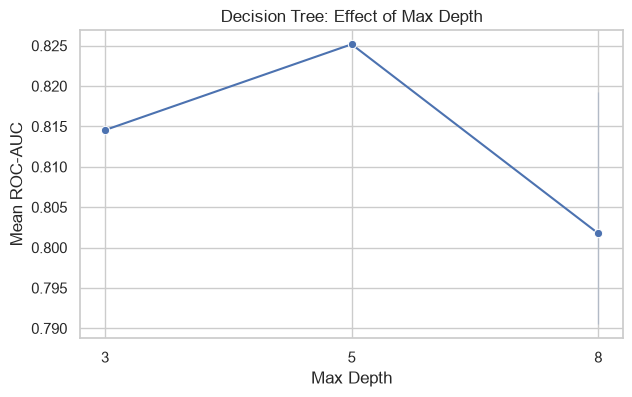

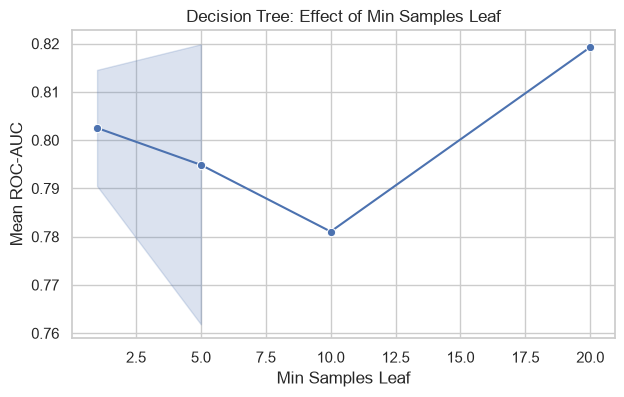

Best Decision Tree values: {'min_samples_leaf': 5, 'max_depth': 5}


In [12]:
dt_results = pd.DataFrame(dt.cv_results_)
dt_results['Max Depth'] = dt_results['param_max_depth'].astype(str)
dt_results['Min Samples Leaf'] = dt_results['param_min_samples_leaf'].astype(int)

plt.figure(figsize=(7, 4))
sns.lineplot(data=dt_results, x='Max Depth', y='mean_test_score', marker='o')
plt.title('Decision Tree: Effect of Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Mean ROC-AUC')
plt.show()

plt.figure(figsize=(7, 4))
sns.lineplot(data=dt_results, x='Min Samples Leaf', y='mean_test_score', marker='o')
plt.title('Decision Tree: Effect of Min Samples Leaf')
plt.xlabel('Min Samples Leaf')
plt.ylabel('Mean ROC-AUC')
plt.show()

print('Best Decision Tree values:', dt.best_params_)


## Decision Tree Visualization



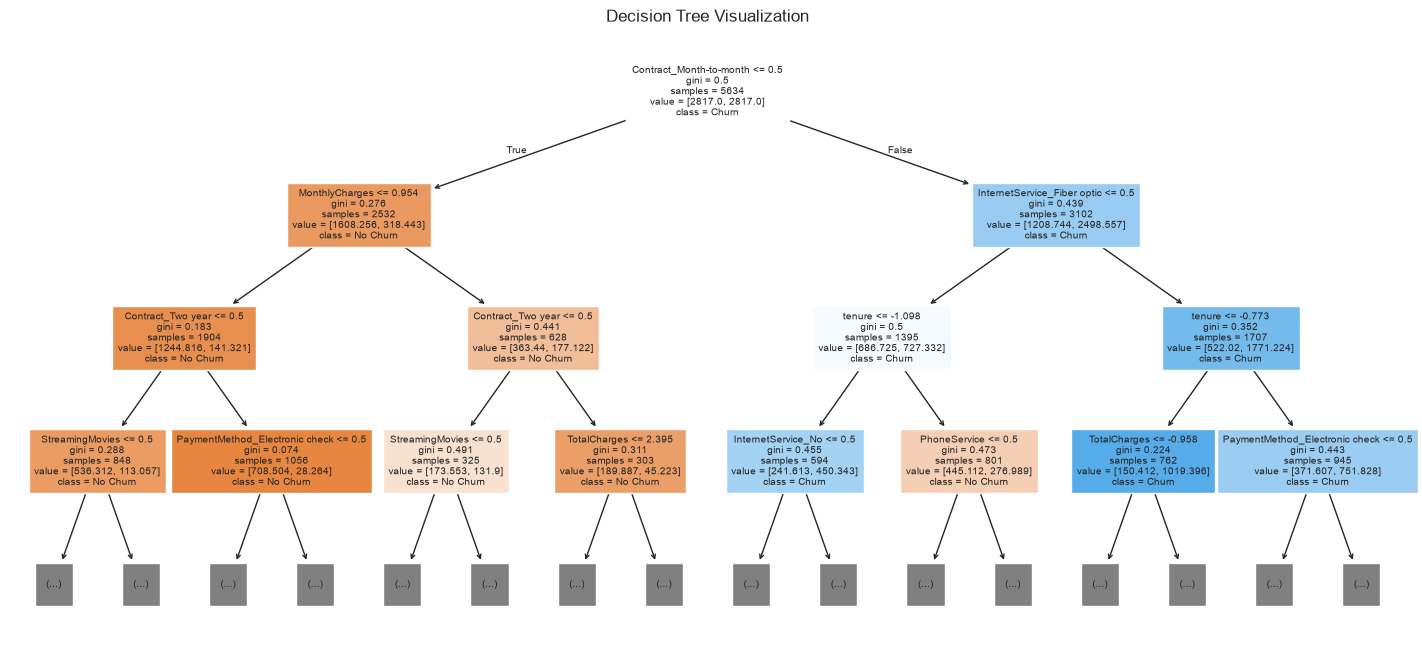

In [13]:

plt.figure(figsize=(18, 8))
plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    max_depth=3,
    fontsize=7
)
plt.title('Decision Tree Visualization')
plt.show()


## K-Nearest Neighbors Hyperparameter Tuning


In [14]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_params,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42
)

knn.fit(X_train, y_train)
best_knn = knn.best_estimator_

print('KNN parameter values tested:', knn_params)
print('Best KNN params:', knn.best_params_)
y_pred_knn, y_prob_knn = show_results(best_knn, X_test, y_test, 'K-Nearest Neighbors')


KNN parameter values tested: {'n_neighbors': [3, 5, 7, 9, 11, 13, 15], 'weights': ['uniform', 'distance'], 'p': [1, 2]}
Best KNN params: {'weights': 'uniform', 'p': 2, 'n_neighbors': 13}
K-Nearest Neighbors Results
Accuracy: 0.7849538679914834
Precision: 0.6011396011396012
Recall: 0.5641711229946524
F1-score: 0.5820689655172414
ROC-AUC: 0.8208672401767032

Confusion Matrix:
[[895 140]
 [163 211]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1035
           1       0.60      0.56      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



## KNN Hyperparameter Graph


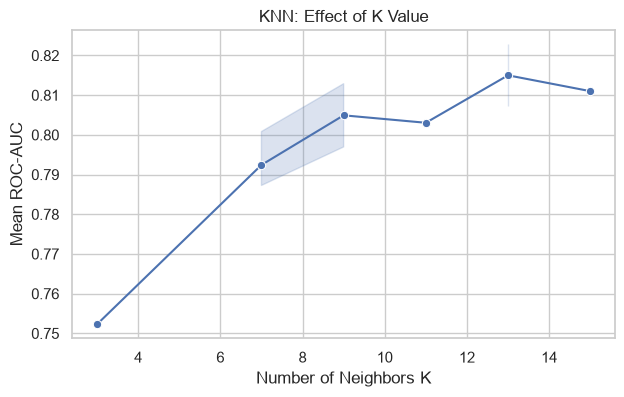

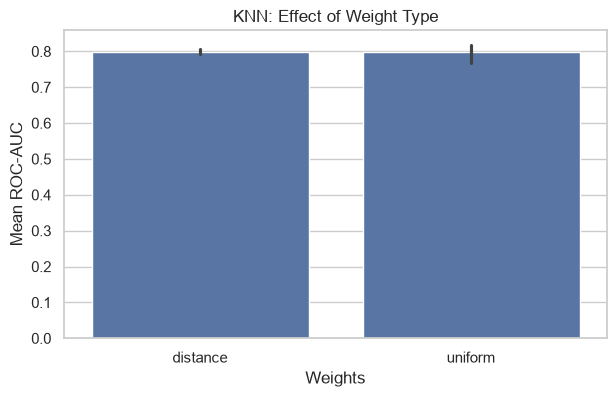

Best KNN values: {'weights': 'uniform', 'p': 2, 'n_neighbors': 13}


In [15]:
knn_results = pd.DataFrame(knn.cv_results_)
knn_results['K Value'] = knn_results['param_n_neighbors'].astype(int)
knn_results['Weight'] = knn_results['param_weights'].astype(str)

plt.figure(figsize=(7, 4))
sns.lineplot(data=knn_results, x='K Value', y='mean_test_score', marker='o')
plt.title('KNN: Effect of K Value')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Mean ROC-AUC')
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=knn_results, x='Weight', y='mean_test_score')
plt.title('KNN: Effect of Weight Type')
plt.xlabel('Weights')
plt.ylabel('Mean ROC-AUC')
plt.show()

print('Best KNN values:', knn.best_params_)


## Random Forest Hyperparameter Tuning


In [16]:
random_forest_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5]
}

rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    random_forest_params,
    n_iter=5,
    scoring='roc_auc',
    cv=3,
    random_state=42
)

rf.fit(X_train, y_train)
best_rf = rf.best_estimator_

print('Random Forest parameter values tested:', random_forest_params)
print('Best Random Forest params:', rf.best_params_)
y_pred_rf, y_prob_rf = show_results(best_rf, X_test, y_test, 'Random Forest')


Random Forest parameter values tested: {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_leaf': [1, 5]}
Best Random Forest params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 5}
Random Forest Results
Accuracy: 0.7366926898509581
Precision: 0.502495840266223
Recall: 0.8074866310160428
F1-score: 0.6194871794871795
ROC-AUC: 0.8413250148544266

Confusion Matrix:
[[736 299]
 [ 72 302]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Random Forest Hyperparameter Graph


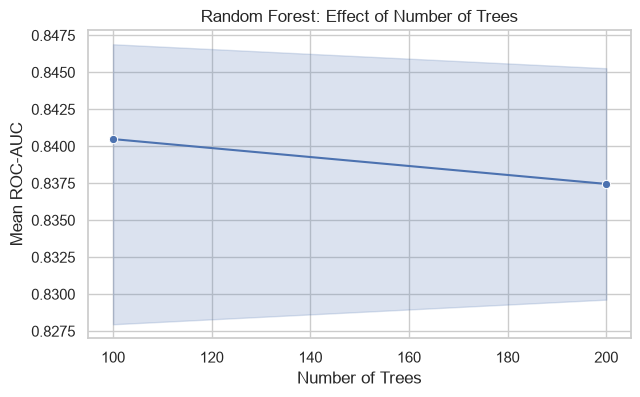

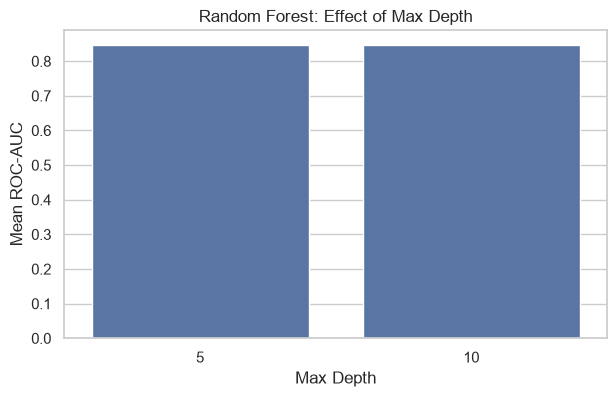

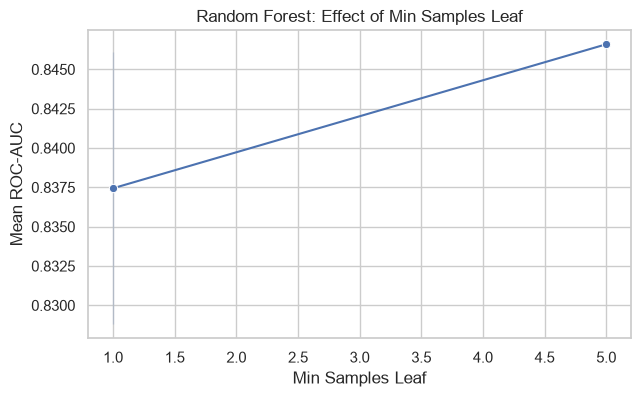

Best Random Forest values: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 5}


In [17]:
rf_results = pd.DataFrame(rf.cv_results_)
rf_results['Number of Trees'] = rf_results['param_n_estimators'].astype(int)
rf_results['Max Depth'] = rf_results['param_max_depth'].astype(str)
rf_results['Min Samples Leaf'] = rf_results['param_min_samples_leaf'].astype(int)

plt.figure(figsize=(7, 4))
sns.lineplot(data=rf_results, x='Number of Trees', y='mean_test_score', marker='o')
plt.title('Random Forest: Effect of Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Mean ROC-AUC')
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=rf_results, x='Max Depth', y='mean_test_score')
plt.title('Random Forest: Effect of Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Mean ROC-AUC')
plt.show()

plt.figure(figsize=(7, 4))
sns.lineplot(data=rf_results, x='Min Samples Leaf', y='mean_test_score', marker='o')
plt.title('Random Forest: Effect of Min Samples Leaf')
plt.xlabel('Min Samples Leaf')
plt.ylabel('Mean ROC-AUC')
plt.show()

print('Best Random Forest values:', rf.best_params_)


## Neural Network Hyperparameter Tuning

A neural network learns patterns using connected layers. Here we tune simple neural network settings and choose the best version using ROC-AUC.


In [18]:
neural_network_params = {
    'hidden_layer_sizes': [(8,), (16,), (32,), (16, 8)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

nn = RandomizedSearchCV(
    MLPClassifier(max_iter=300, random_state=42),
    neural_network_params,
    n_iter=8,
    scoring='roc_auc',
    cv=3,
    random_state=42
)

nn.fit(X_train, y_train)
best_nn = nn.best_estimator_

print('Neural Network parameter values tested:', neural_network_params)
print('Best Neural Network params:', nn.best_params_)
y_pred_nn, y_prob_nn = show_results(best_nn, X_test, y_test, 'Neural Network')


Neural Network parameter values tested: {'hidden_layer_sizes': [(8,), (16,), (32,), (16, 8)], 'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001], 'learning_rate_init': [0.001, 0.01]}
Best Neural Network params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (8,), 'alpha': 0.001, 'activation': 'relu'}
Neural Network Results
Accuracy: 0.7955997161107168
Precision: 0.6452702702702703
Recall: 0.5106951871657754
F1-score: 0.5701492537313433
ROC-AUC: 0.8401844532279314

Confusion Matrix:
[[930 105]
 [183 191]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## Neural Network Hyperparameter Graph


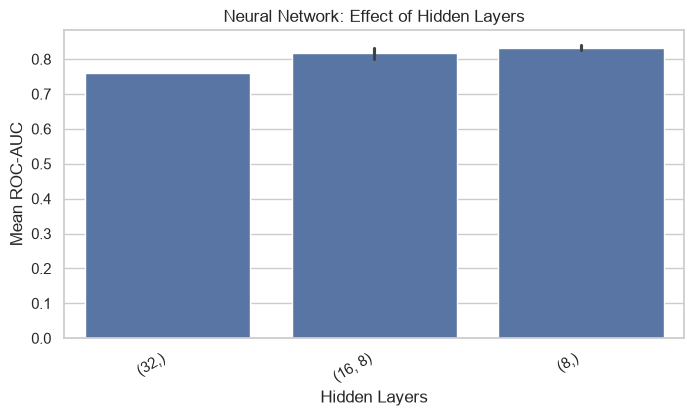

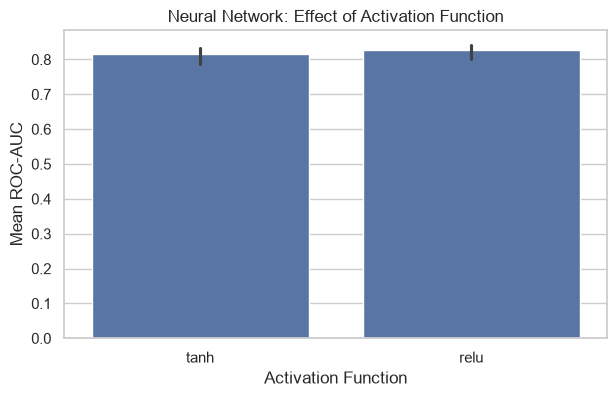

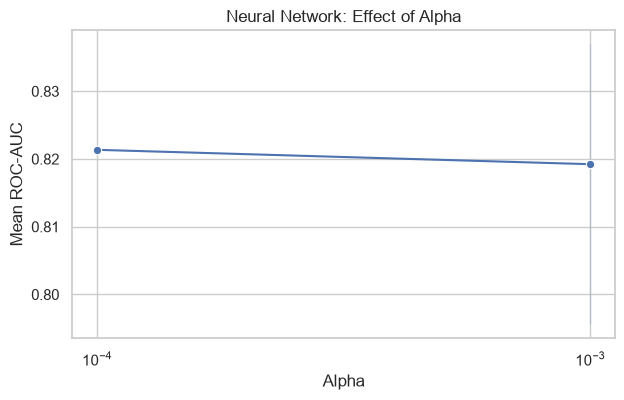

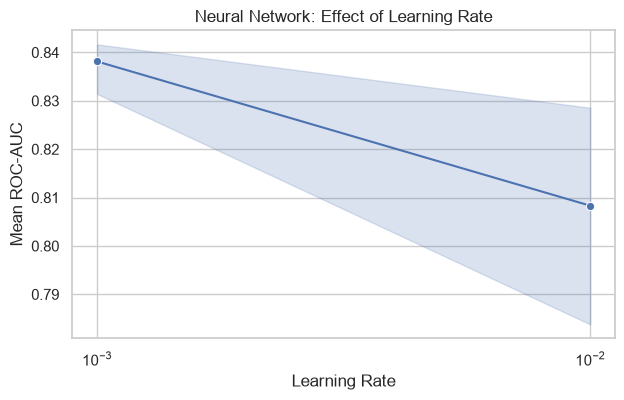

Best Neural Network values: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (8,), 'alpha': 0.001, 'activation': 'relu'}


In [19]:
nn_results = pd.DataFrame(nn.cv_results_)
nn_results['Hidden Layers'] = nn_results['param_hidden_layer_sizes'].astype(str)
nn_results['Activation'] = nn_results['param_activation'].astype(str)
nn_results['Alpha'] = nn_results['param_alpha'].astype(float)
nn_results['Learning Rate'] = nn_results['param_learning_rate_init'].astype(float)

plt.figure(figsize=(8, 4))
sns.barplot(data=nn_results, x='Hidden Layers', y='mean_test_score')
plt.title('Neural Network: Effect of Hidden Layers')
plt.xlabel('Hidden Layers')
plt.ylabel('Mean ROC-AUC')
plt.xticks(rotation=30, ha='right')
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=nn_results, x='Activation', y='mean_test_score')
plt.title('Neural Network: Effect of Activation Function')
plt.xlabel('Activation Function')
plt.ylabel('Mean ROC-AUC')
plt.show()

plt.figure(figsize=(7, 4))
sns.lineplot(data=nn_results, x='Alpha', y='mean_test_score', marker='o')
plt.xscale('log')
plt.title('Neural Network: Effect of Alpha')
plt.xlabel('Alpha')
plt.ylabel('Mean ROC-AUC')
plt.show()

plt.figure(figsize=(7, 4))
sns.lineplot(data=nn_results, x='Learning Rate', y='mean_test_score', marker='o')
plt.xscale('log')
plt.title('Neural Network: Effect of Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Mean ROC-AUC')
plt.show()

print('Best Neural Network values:', nn.best_params_)


## Neural Network Evaluation Visuals


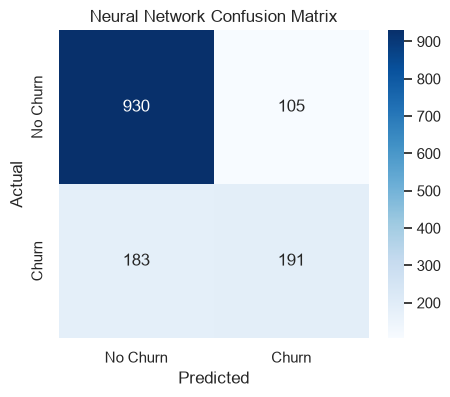

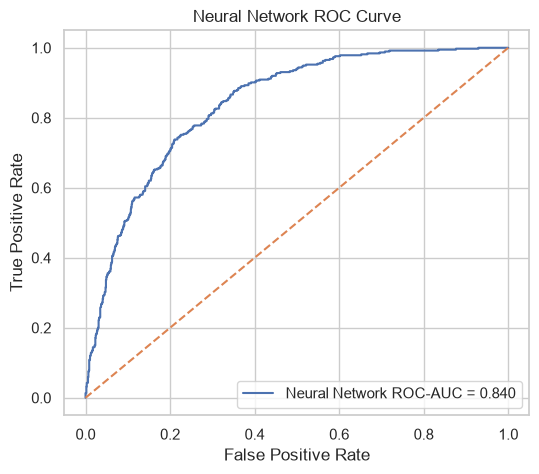

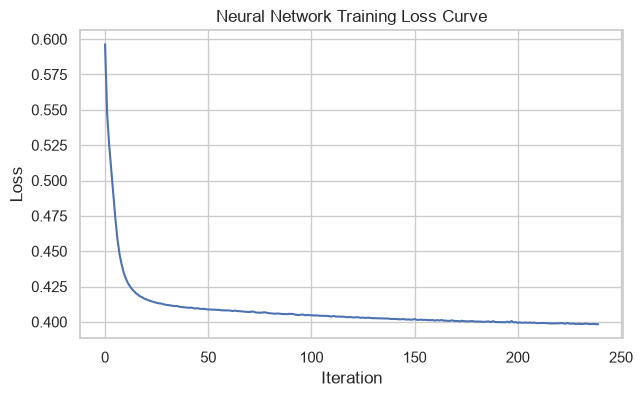

In [20]:
plt.figure(figsize=(5, 4))
nn_matrix = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(
    nn_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)

plt.figure(figsize=(6, 5))
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network ROC-AUC = {roc_auc_score(y_test, y_prob_nn):.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Neural Network ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

if hasattr(best_nn, 'loss_curve_'):
    plt.figure(figsize=(7, 4))
    plt.plot(best_nn.loss_curve_)
    plt.title('Neural Network Training Loss Curve')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.show()


## Comparing Models

This table compares all m
odels using the same metrics.


In [21]:
classification_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors', 'Random Forest', 'Neural Network'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_nn)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_nn)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_knn), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_nn)],
    'F1-score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_nn)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_dt), roc_auc_score(y_test, y_prob_knn), roc_auc_score(y_test, y_prob_rf), roc_auc_score(y_test, y_prob_nn)]
})

classification_results = classification_results.sort_values('ROC-AUC', ascending=False)
classification_results


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Random Forest,0.736693,0.502496,0.807487,0.619487,0.841325
0,Logistic Regression,0.738112,0.504318,0.780749,0.612802,0.840275
4,Neural Network,0.795600,0.645270,0.510695,0.570149,0.840184
1,Decision Tree,0.755855,0.526690,0.791444,0.632479,0.835304
2,K-Nearest Neighbors,0.784954,0.601140,0.564171,0.582069,0.820867


## Model Comparison

This chart makes it easier to see which model has the highest ROC-AUC score.


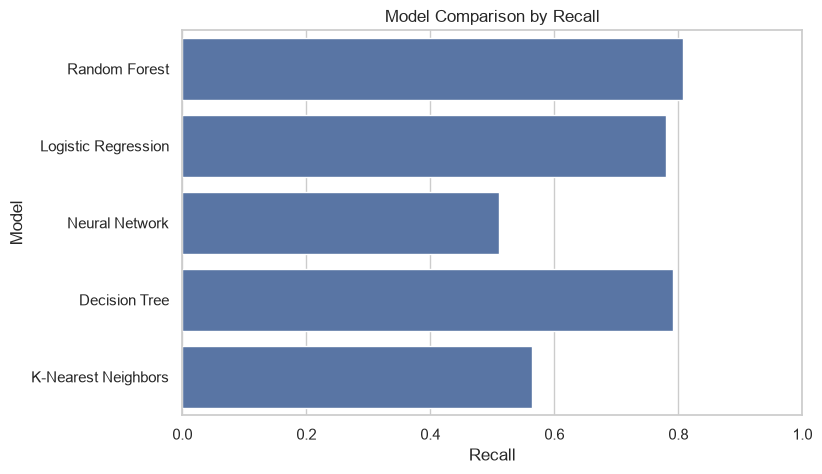

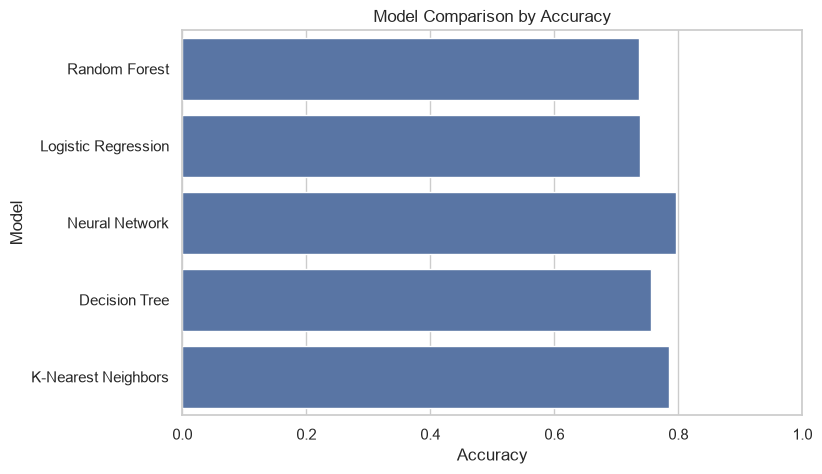

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=classification_results, x='Recall', y='Model')
plt.title('Model Comparison by Recall')
plt.xlim(0, 1)
plt.show()


plt.figure(figsize=(8, 5))
sns.barplot(data=classification_results, x='Accuracy', y='Model')
plt.title('Model Comparison by Accuracy')
plt.xlim(0, 1)
plt.show()


## Confusion Matrix For Each Model


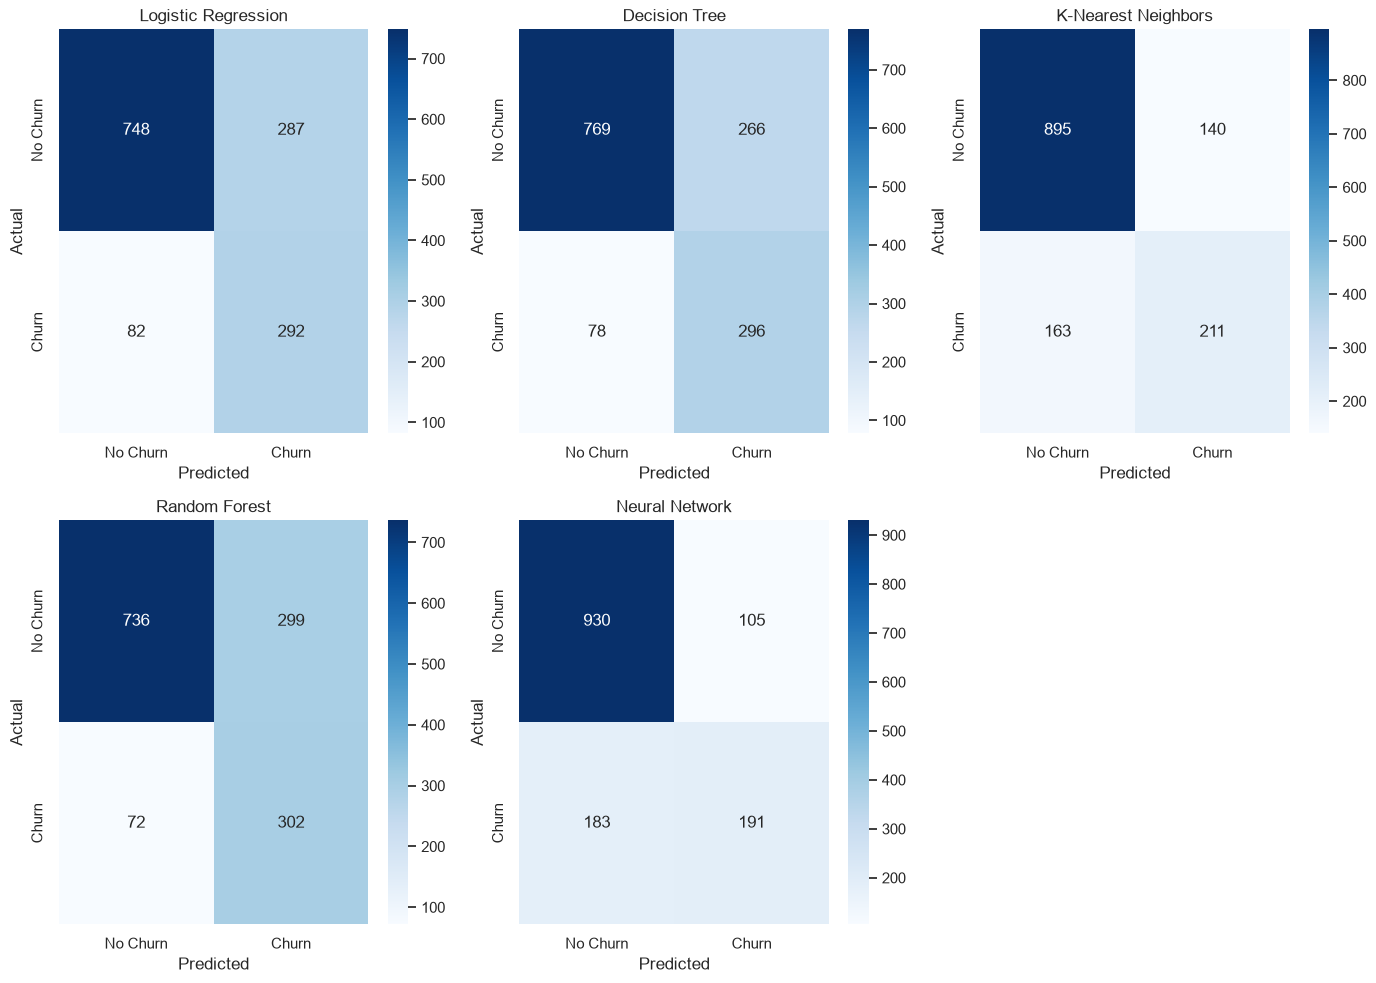

In [23]:
model_predictions = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'K-Nearest Neighbors': y_pred_knn,
    'Random Forest': y_pred_rf,
    'Neural Network': y_pred_nn
}

plt.figure(figsize=(14, 10))

for i, (model_name, predictions) in enumerate(model_predictions.items(), start=1):
    plt.subplot(2, 3, i)
    matrix = confusion_matrix(y_test, predictions)
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn']
    )
    plt.title(model_name)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()


## Clustering Evaluation: Inertia


,K Value,Inertia
0,2,9713.264019
1,3,6187.000305
2,4,4151.006813
3,5,3113.461015
4,6,2564.825485
5,7,2181.785873
6,8,1887.464226


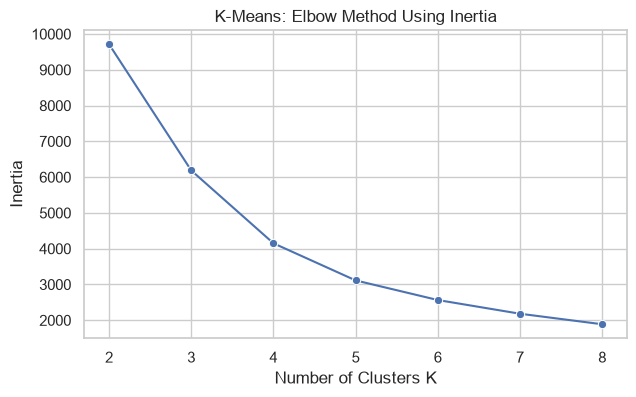

In [24]:
cluster_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
cluster_data = data[cluster_columns]

cluster_scaler = StandardScaler()
cluster_data_scaled = cluster_scaler.fit_transform(cluster_data)

kmeans_results = []

for k in [2, 3, 4, 5, 6, 7, 8]:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(cluster_data_scaled)

    kmeans_results.append({
        'K Value': k,
        'Inertia': kmeans_model.inertia_,
        'Silhouette Score': silhouette_score(cluster_data_scaled, cluster_labels)
    })

kmeans_results = pd.DataFrame(kmeans_results)
display(kmeans_results[['K Value', 'Inertia']])

plt.figure(figsize=(7, 4))
sns.lineplot(data=kmeans_results, x='K Value', y='Inertia', marker='o')
plt.title('K-Means: Elbow Method Using Inertia')
plt.xlabel('Number of Clusters K')
plt.ylabel('Inertia')
plt.show()


## Clustering Evaluation: Silhouette Score


,K Value,Silhouette Score
0,2,0.479731
1,3,0.451358
2,4,0.471967
3,5,0.443509
4,6,0.437463
5,7,0.430740
6,8,0.433588


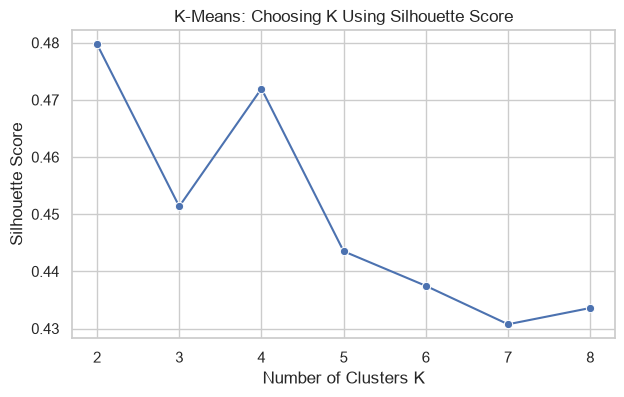

Best K value by Silhouette Score: 2
Best Silhouette Score: 0.4797310580369739


In [25]:
display(kmeans_results[['K Value', 'Silhouette Score']])

plt.figure(figsize=(7, 4))
sns.lineplot(data=kmeans_results, x='K Value', y='Silhouette Score', marker='o')
plt.title('K-Means: Choosing K Using Silhouette Score')
plt.xlabel('Number of Clusters K')
plt.ylabel('Silhouette Score')
plt.show()

best_kmeans = kmeans_results.sort_values('Silhouette Score', ascending=False).iloc[0]
best_k = int(best_kmeans['K Value'])

print('Best K value by Silhouette Score:', best_k)
print('Best Silhouette Score:', best_kmeans['Silhouette Score'])


#
 K-Means Clustering



In [26]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(cluster_data_scaled)

print(data[['tenure', 'MonthlyCharges', 'TotalCharges', 'Cluster']].head())


   tenure  MonthlyCharges  TotalCharges  Cluster
0       1           29.85         29.85        0
1      34           56.95       1889.50        0
2       2           53.85        108.15        0
3      45           42.30       1840.75        0
4       2           70.70        151.65        0


## Clustering Plot


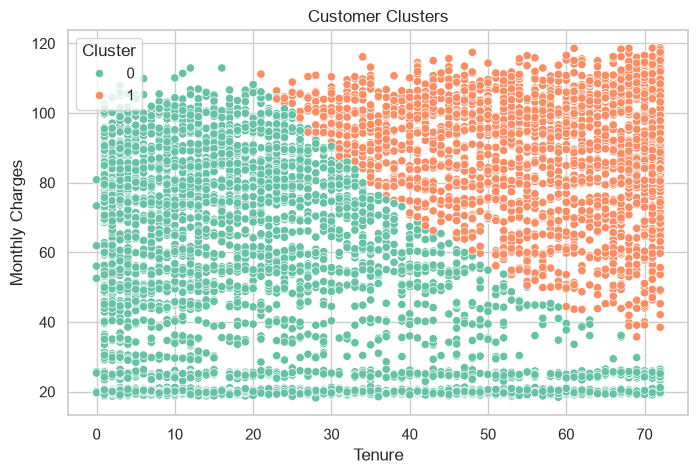

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=data,
    x='tenure',
    y='MonthlyCharges',
    hue='Cluster',
    palette='Set2'
)
plt.title('Customer Clusters')
plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')
plt.show()


## Regression Analysis Concept


Linear Regression R2: 0.6920118823860495
Linear Regression MAE: 12.95626400258756


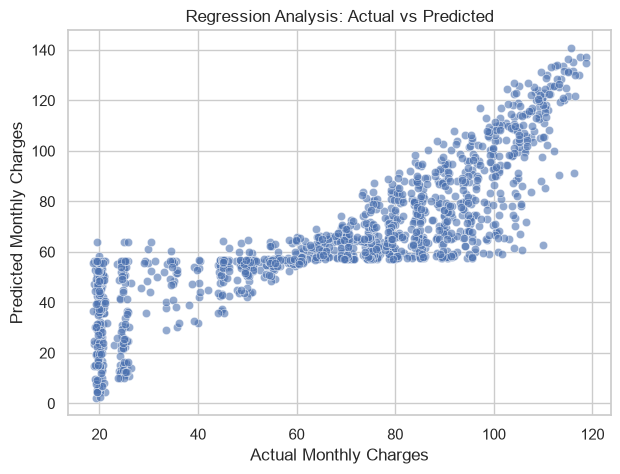

In [28]:
regression_data = data[['SeniorCitizen', 'tenure', 'TotalCharges', 'MonthlyCharges']]
X_reg = regression_data.drop('MonthlyCharges', axis=1)
y_reg = regression_data['MonthlyCharges']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

linear_regression = LinearRegression()
linear_regression.fit(X_train_reg, y_train_reg)
y_pred_reg = linear_regression.predict(X_test_reg)

print('Linear Regression R2:', r2_score(y_test_reg, y_pred_reg))
print('Linear Regression MAE:', mean_absolute_error(y_test_reg, y_pred_reg))

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.6)
plt.xlabel('Actual Monthly Charges')
plt.ylabel('Predicted Monthly Charges')
plt.title('Regression Analysis: Actual vs Predicted')
plt.show()


## Final Notes

The best model is Random Tree and K nearest numbers


